# Iris flower classification with Groovy

The classic [UCI Iris dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/):
sepal/petal measurements and known species for 150 flowers — classified here
with k-nearest-neighbours, ported from the BeakerX-era `Iris.ipynb` in
[groovy-data-science](https://github.com/paulk-asert/groovy-data-science).

CSV parsing uses `groovy-csv`'s `CsvSlurper` and per-species stats use GINQ —
both ship with the kernel, no grabs needed. Smile is pinned to 1.5.3 (the last
Apache-2.0-licensed release), and instead of Smile's `CrossValidation` we
hand-roll leave-one-out cross-validation in a few lines of Groovy.

The dataset (`iris_data.csv`, alongside this notebook) is copied from
groovy-data-science so the example is self-contained — see
`iris_data_source.txt` for provenance.

In [17]:
@Grab('com.github.haifengl:smile-core:1.5.3')
import groovy.csv.CsvSlurper
import smile.classification.KNN
'deps ready'

deps ready

In [18]:
raw = new CsvSlurper().parse(new File('iris_data.csv'))
flowers = raw.collect { [species: it.Class,
    sepalLength: it.'Sepal length' as double, sepalWidth: it.'Sepal width' as double,
    petalLength: it.'Petal length' as double, petalWidth: it.'Petal width' as double] }
"${flowers.size()} flowers, ${flowers*.species.unique().size()} species"

150 flowers, 3 species

In [19]:
flowers.take(5)

species,sepalLength,sepalWidth,petalLength,petalWidth
Iris-setosa,5.1,3.5,1.4,0.2
Iris-setosa,4.9,3.0,1.4,0.2
Iris-setosa,4.7,3.2,1.3,0.2
Iris-setosa,4.6,3.1,1.5,0.2
Iris-setosa,5.0,3.6,1.4,0.2


In [20]:
flowers.countBy { it.species }

key,value
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


Per-species petal-length statistics with GINQ, using the `groupby ... into`
clause new in Groovy 6 — the group becomes a first-class object (`g`) with
`g.key` and explicit aggregate lambdas, so post-processing an aggregate
(like rounding the mean) is just a method call:

In [21]:
GQ {
    from f in flowers
    groupby f.species into g
    select g.key as species, g.min(f -> f.petalLength) as min,
           (g.avg(f -> f.petalLength) as double).round(2) as mean,
           g.max(f -> f.petalLength) as max
}

species,min,mean,max
Iris-versicolor,3.0,4.26,5.1
Iris-virginica,4.5,5.55,6.9
Iris-setosa,1.0,1.46,1.9


Train k-NN (k=3) and score it with leave-one-out cross-validation — for each
flower, train on the other 149 and predict the held-out one:

In [22]:
names = flowers*.species.unique()
features = flowers.collect { [it.sepalLength, it.sepalWidth, it.petalLength, it.petalWidth] as double[] } as double[][]
labels = flowers.collect { names.indexOf(it.species) } as int[]
predictions = (0..<features.length).collect { i ->
    def keep = (0..<features.length) - i
    def trainX = keep.collect { features[it] } as double[][]
    def trainY = keep.collect { labels[it] } as int[]
    KNN.learn(trainX, trainY, 3).predict(features[i])
}
correct = (0..<labels.length).count { predictions[it] == labels[it] }
"LOOCV accuracy: ${(100 * correct / labels.length).round(1)}% ($correct/${labels.length})"

LOOCV accuracy: 96.0% (144/150)

The confusion matrix as a plain list of maps (auto-rendered as a table):

In [23]:
tally = [:].withDefault { 0 }
predictions.eachWithIndex { p, i -> tally[[names[labels[i]], names[p]]] += 1 }
names.collect { actual ->
    [actual: actual] + names.collectEntries { predicted -> [predicted, tally[[actual, predicted]]] }
}

actual,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,50,0,0
Iris-versicolor,0,47,3
Iris-virginica,0,3,47


Petal length vs width, colored by *predicted* species; the handful of
misclassified flowers get a black ring (hover for actual vs predicted):

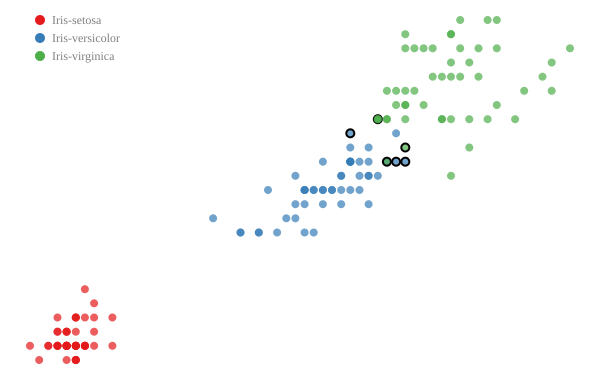

In [24]:
palette = ['#e41a1c', '#377eb8', '#4daf4a']
xs = flowers*.petalLength
ys = flowers*.petalWidth
minX = xs.min(); maxX = xs.max(); minY = ys.min(); maxY = ys.max()
sx = { v -> (30 + 540 * (v - minX) / (maxX - minX)).round(1) }
sy = { v -> (20 + 340 * (maxY - v) / (maxY - minY)).round(1) }
dots = (0..<flowers.size()).collect { i ->
    def wrong = predictions[i] != labels[i]
    def ring = wrong ? " stroke='black' stroke-width='2'" : ''
    def note = wrong ? "${names[labels[i]]} (predicted ${names[predictions[i]]})" : names[labels[i]]
    "<circle cx='${sx(xs[i])}' cy='${sy(ys[i])}' r='4' fill='${palette[predictions[i]]}' fill-opacity='0.7'$ring><title>$note</title></circle>"
}.join('\n')
legend = (0..<names.size()).collect { i ->
    "<circle cx='40' cy='${20 + 18 * i}' r='5' fill='${palette[i]}'/><text x='52' y='${24 + 18 * i}' font-size='12' fill='gray'>${names[i]}</text>"
}.join('\n')
displaySvg("<svg xmlns='http://www.w3.org/2000/svg' width='600' height='380'>\n$dots\n$legend\n</svg>")
HIDDEN